# Notebook 03: Maps and Export
## EV Charging Gap Analysis — Texas Triangle Freight Corridor

This notebook produces three publication-quality static maps and exports layers for ArcGIS Online.

**Maps produced:**
1. Overview — full corridor, all chargers, desert zones
2. Worst Gap Zoom — close-up of the longest charging desert
3. Distance Heatmap — color gradient of coverage quality

**Exports:** GeoJSON files sized for ArcGIS Online upload (<10 MB each)

---
## Cell 1: Imports and Paths

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
import numpy as np
import shutil
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

BASE = Path('/Users/nadhirahendra/Documents/02-areas/QMSSGR5070-GIS/portfolio/post04-ev-charging-gap')
PROCESSED  = BASE / 'data' / 'processed'
MAPS_OUT   = BASE / 'output' / 'maps'
SHAPES_OUT = BASE / 'output' / 'shapefiles'

MAPS_OUT.mkdir(parents=True, exist_ok=True)
SHAPES_OUT.mkdir(parents=True, exist_ok=True)

# Web Mercator for contextily basemaps
WEB = 'EPSG:3857'

print('Ready.')

Ready.


---
## Cell 2: Load All Layers

> **Why EPSG:3857?** Contextily basemaps (OpenStreetMap, CartoDB, etc.) are served in Web Mercator (EPSG:3857). For the basemap to align with your data, everything needs to be in the same projection when plotting. We reproject to 3857 only for visualization — the underlying analysis data stays in UTM.

In [2]:
print('Loading layers...')

counties    = gpd.read_file(PROCESSED / 'tx_counties.geojson').to_crs(WEB)
hwys        = gpd.read_file(PROCESSED / 'triangle_hwys.geojson').to_crs(WEB)
corridor    = gpd.read_file(PROCESSED / 'corridor_buffer.geojson').to_crs(WEB)
chargers    = gpd.read_file(PROCESSED / 'chargers_in_corridor.geojson').to_crs(WEB)
gap_pts     = gpd.read_file(PROCESSED / 'gap_analysis.geojson').to_crs(WEB)
truck_stops = gpd.read_file(PROCESSED / 'truck_stops_corridor.geojson').to_crs(WEB)

desert_pts = gap_pts[gap_pts['is_desert'] == 1]
covered_pts = gap_pts[gap_pts['is_desert'] == 0]

print(f'Counties:          {len(counties):,}')
print(f'Highway segments:  {len(hwys):,}')
print(f'Chargers:          {len(chargers):,}')
print(f'Sample points:     {len(gap_pts):,}')
print(f'  Desert points:   {len(desert_pts):,}')
print(f'Truck stops:       {len(truck_stops):,}')

Loading layers...


Counties:          254
Highway segments:  215
Chargers:          629
Sample points:     750
  Desert points:   0
Truck stops:       140


---
## Cell 3: Map 1 — Overview Map

> **Reading the map:** Green dots = DC Fast chargers (where trucks can charge). Red dots = charging desert sample points (more than 50 miles from a charger). Gray triangles = truck stops (where trucks stop today, but no fast charging). The blue corridor shows the 25-mile zone around the three highways.

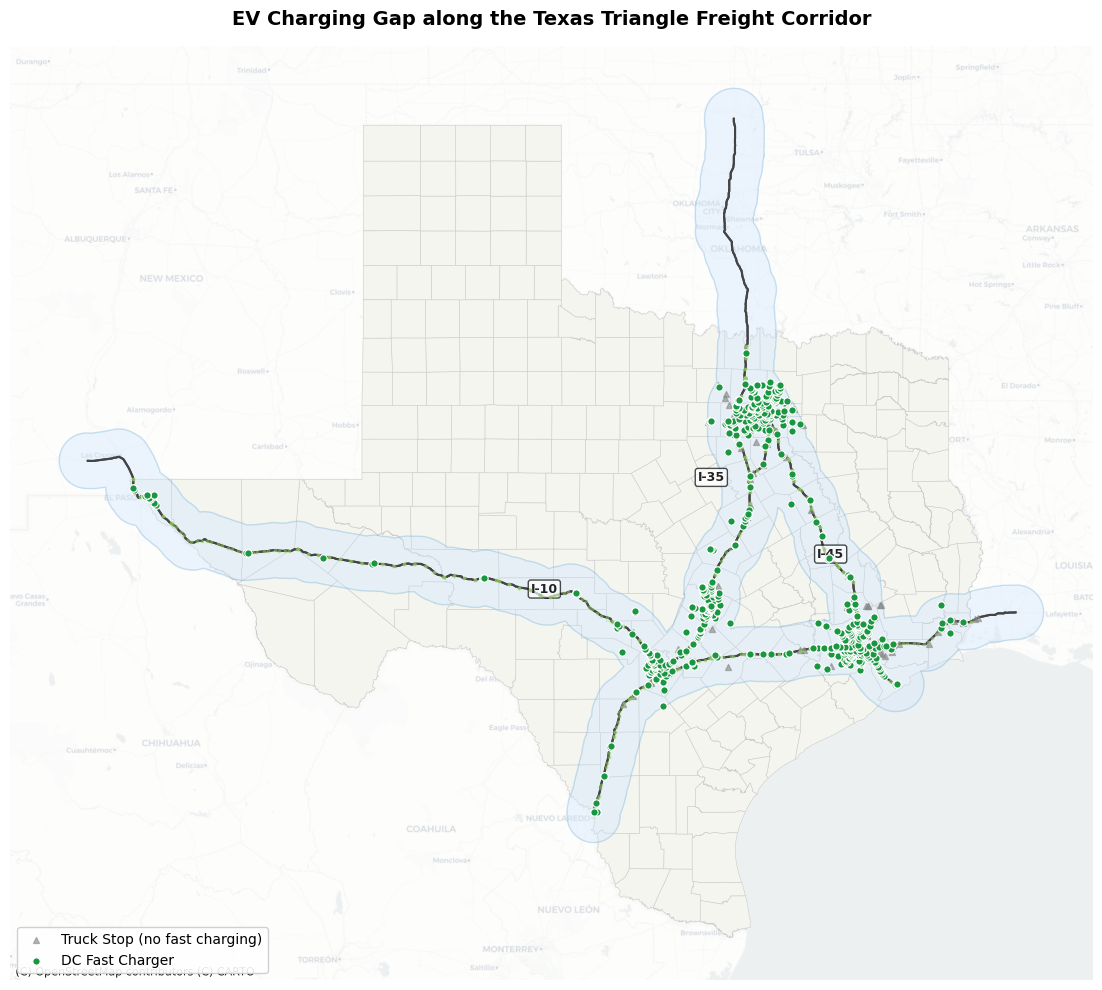

Saved: /Users/nadhirahendra/Documents/02-areas/QMSSGR5070-GIS/portfolio/post04-ev-charging-gap/output/maps/Map01_Overview.png


In [3]:
fig, ax = plt.subplots(figsize=(14, 10))

# Layer 1: Texas counties (light background)
counties.plot(ax=ax, color='#f5f5f0', edgecolor='#cccccc', linewidth=0.4, zorder=1)

# Layer 2: Corridor buffer (transparent blue)
corridor.plot(ax=ax, color='#cce5ff', alpha=0.35, edgecolor='#6baed6', linewidth=1, zorder=2)

# Layer 3: Highways
hwys.plot(ax=ax, color='#444444', linewidth=1.5, zorder=3)

# Layer 4: Truck stops
truck_stops.plot(ax=ax, color='#888888', marker='^', markersize=18,
                 alpha=0.6, zorder=4, label='Truck Stop (no fast charging)')

# Layer 5: Desert sample points (red)
if len(desert_pts) > 0:
    desert_pts.plot(ax=ax, color='#d73027', markersize=6,
                    alpha=0.6, zorder=5, label=f'Charging Desert (>{50} mi gap)')

# Layer 6: Covered sample points (light green, small)
covered_pts.plot(ax=ax, color='#91cf60', markersize=3,
                 alpha=0.4, zorder=5)

# Layer 7: DC Fast chargers (green dots, prominent)
chargers.plot(ax=ax, color='#1a9641', marker='o', markersize=28,
              edgecolor='white', linewidth=0.8, zorder=6, label='DC Fast Charger')

# Basemap
try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=7, alpha=0.4)
except Exception:
    pass  # Basemap is optional — continue without it if offline

# Legend and labels
ax.legend(loc='lower left', fontsize=10, framealpha=0.9)
ax.set_title('EV Charging Gap along the Texas Triangle Freight Corridor',
             fontsize=14, fontweight='bold', pad=15)
ax.set_axis_off()

# Highway labels
# Approximate label positions (Web Mercator coords)
hwys_4326 = gpd.read_file(PROCESSED / 'triangle_hwys.geojson')
for label in ['I- 10', 'I- 35', 'I- 45']:
    subset = hwys_4326[hwys_4326['FULLNAME'].str.contains(label.replace('- ', '-\\s*'), regex=True, na=False)]
    if not subset.empty:
        mid = subset.dissolve().centroid.to_crs(WEB).iloc[0]
        clean_label = label.replace('- ', '-')
        ax.annotate(clean_label, (mid.x, mid.y), fontsize=9, fontweight='bold',
                    color='#222222', ha='center',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

plt.tight_layout()
out_path = MAPS_OUT / 'Map01_Overview.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

---
## Cell 4: Map 2 — Worst Gap Zoom

> **What this map shows:** We find the single sample point with the largest distance to the nearest charger and zoom in to show that stretch of highway. This is your strongest visual — it shows exactly where a truck driver would get stranded today.

Worst gap: 47.5 miles on I-10


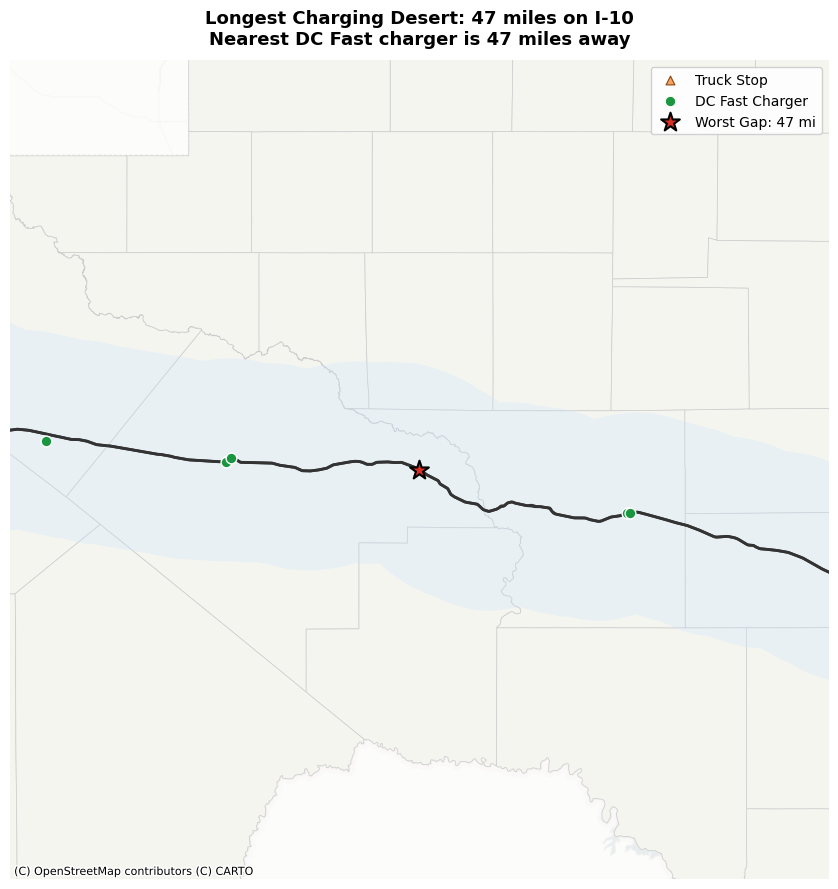

Saved: /Users/nadhirahendra/Documents/02-areas/QMSSGR5070-GIS/portfolio/post04-ev-charging-gap/output/maps/Map02_Worst_Gap.png


In [4]:
# Find the worst gap point
worst_idx = gap_pts['dist_mi'].idxmax()
worst_pt  = gap_pts.loc[worst_idx]
worst_dist = worst_pt['dist_mi']
worst_hwy  = worst_pt.get('highway', 'Unknown')

print(f'Worst gap: {worst_dist:.1f} miles on {worst_hwy}')

# Build a bounding box around the worst point — zoom to ±120 miles
ZOOM_M = 120 * 1609.34  # 120 miles in meters
cx, cy = worst_pt.geometry.x, worst_pt.geometry.y
bbox = (cx - ZOOM_M, cy - ZOOM_M, cx + ZOOM_M, cy + ZOOM_M)

fig, ax = plt.subplots(figsize=(12, 9))

# Background counties
counties.plot(ax=ax, color='#f5f5f0', edgecolor='#cccccc', linewidth=0.5, zorder=1)

# Corridor
corridor.plot(ax=ax, color='#cce5ff', alpha=0.3, edgecolor='none', zorder=2)

# All desert points in region
if len(desert_pts) > 0:
    desert_pts.plot(ax=ax, color='#d73027', markersize=12, alpha=0.7,
                    zorder=4, label='Charging Desert (>50 mi gap)')

# Highways
hwys.plot(ax=ax, color='#333333', linewidth=2, zorder=5)

# Truck stops
truck_stops.plot(ax=ax, color='#f4a460', marker='^', markersize=40,
                 edgecolor='#8b4513', linewidth=0.8, zorder=6, label='Truck Stop')

# Chargers
chargers.plot(ax=ax, color='#1a9641', marker='o', markersize=60,
              edgecolor='white', linewidth=1, zorder=7, label='DC Fast Charger')

# Highlight the worst point
ax.scatter([cx], [cy], color='#d73027', s=200, marker='*',
           edgecolor='black', linewidth=1.5, zorder=8, label=f'Worst Gap: {worst_dist:.0f} mi')

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=8, alpha=0.5)
except Exception:
    pass

# Zoom to the region
ax.set_xlim(bbox[0], bbox[2])
ax.set_ylim(bbox[1], bbox[3])

ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.set_title(f'Longest Charging Desert: {worst_dist:.0f} miles on {worst_hwy}\n'
             f'Nearest DC Fast charger is {worst_dist:.0f} miles away',
             fontsize=13, fontweight='bold', pad=12)
ax.set_axis_off()

plt.tight_layout()
out_path = MAPS_OUT / 'Map02_Worst_Gap.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

---
## Cell 5: Map 3 — Distance Heatmap

> **How to read this map:** Each dot is a sample point along the route, colored by how far it is from the nearest DC Fast charger. Dark green means well-covered. Yellow means marginal. Red means desert. The distribution of colors tells you where coverage is worst and which highway is most at-risk.

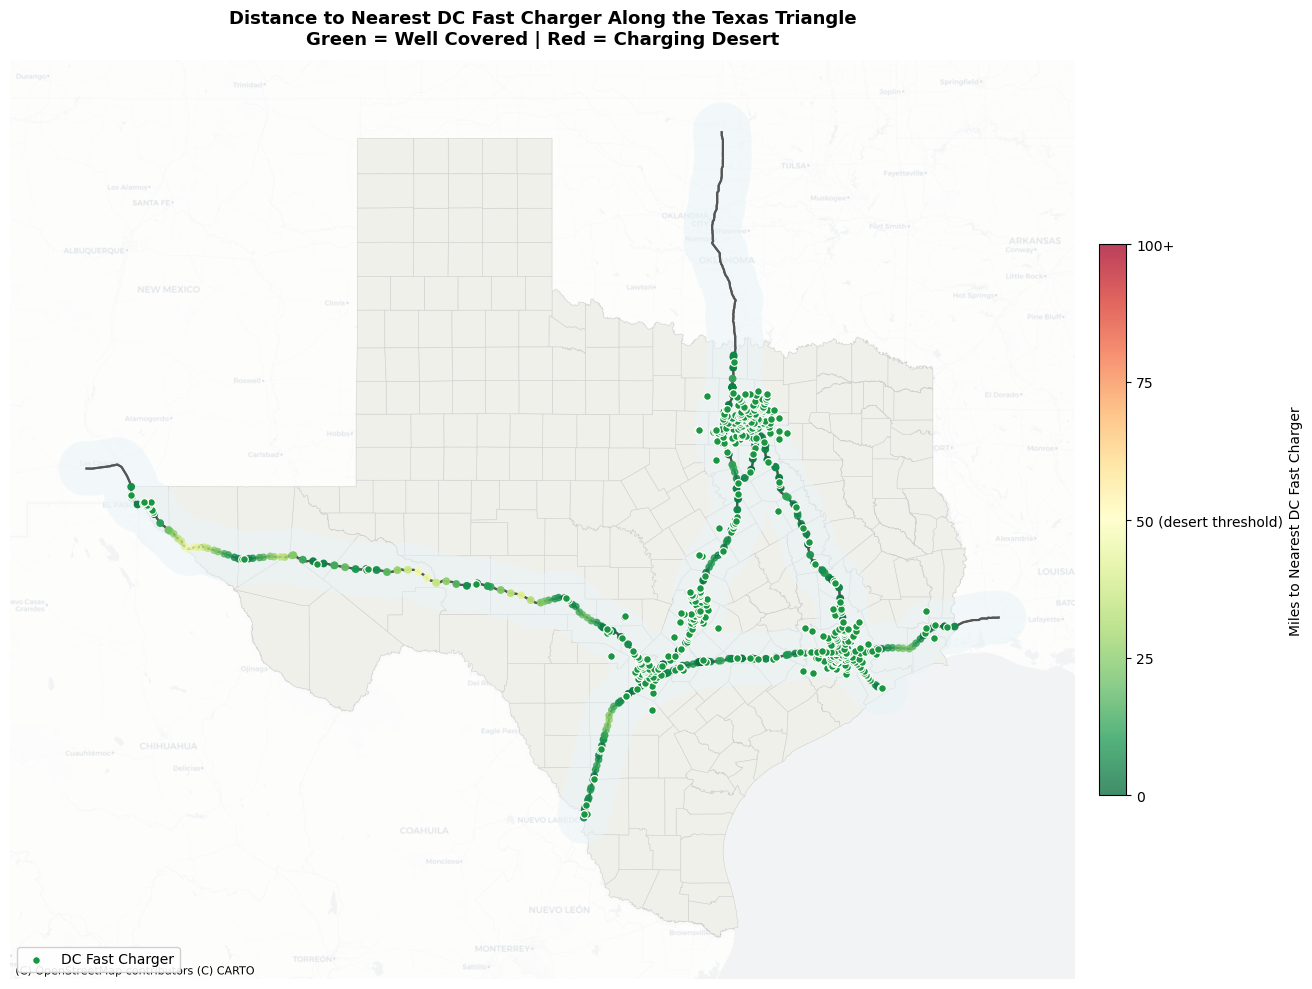

Saved: /Users/nadhirahendra/Documents/02-areas/QMSSGR5070-GIS/portfolio/post04-ev-charging-gap/output/maps/Map03_Distance_Heatmap.png


In [5]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(14, 10))

# Background
counties.plot(ax=ax, color='#f0f0eb', edgecolor='#d0d0d0', linewidth=0.4, zorder=1)
corridor.plot(ax=ax, color='#e8f4f8', alpha=0.5, edgecolor='none', zorder=2)
hwys.plot(ax=ax, color='#555555', linewidth=1.5, zorder=3)

# Color scale: green (0 mi) → yellow (50 mi) → red (100+ mi)
cmap = plt.cm.RdYlGn_r  # Red-Yellow-Green reversed (red = bad = far)
norm = mcolors.Normalize(vmin=0, vmax=100)

# Plot all sample points colored by distance
scatter = ax.scatter(
    gap_pts.geometry.x,
    gap_pts.geometry.y,
    c=gap_pts['dist_mi'].clip(upper=100),
    cmap=cmap,
    norm=norm,
    s=20,
    alpha=0.75,
    zorder=4
)

# Charger locations
chargers.plot(ax=ax, color='#1a9641', marker='o', markersize=30,
              edgecolor='white', linewidth=0.8, zorder=6, label='DC Fast Charger')

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=7, alpha=0.3)
except Exception:
    pass

# Colorbar
cbar = plt.colorbar(scatter, ax=ax, orientation='vertical',
                    fraction=0.025, pad=0.02, shrink=0.6)
cbar.set_label('Miles to Nearest DC Fast Charger', fontsize=10)
cbar.set_ticks([0, 25, 50, 75, 100])
cbar.set_ticklabels(['0', '25', '50 (desert threshold)', '75', '100+'])

ax.legend(loc='lower left', fontsize=10, framealpha=0.9)
ax.set_title('Distance to Nearest DC Fast Charger Along the Texas Triangle\n'
             'Green = Well Covered | Red = Charging Desert',
             fontsize=13, fontweight='bold', pad=12)
ax.set_axis_off()

plt.tight_layout()
out_path = MAPS_OUT / 'Map03_Distance_Heatmap.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

---
## Cell 6: Export GeoJSON Files for ArcGIS Online

> **ArcGIS Online upload limit:** Individual files must be under 10 MB. We drop unnecessary columns and simplify geometries slightly to keep files small. The analysis data is preserved — we only trim metadata columns that are not needed for the web map.

In [6]:
# Re-load in EPSG:4326 for export (ArcGIS Online expects WGS84)
exports = {
    'corridor_buffer.geojson':        ('corridor_buffer.geojson', None),
    'chargers_in_corridor.geojson':   ('chargers_in_corridor.geojson', 
                                       ['Station Name', 'City', 'EV DC Fast Count', 'EV Network', 'geometry']),
    'gap_analysis.geojson':           ('gap_analysis.geojson',
                                       ['highway', 'dist_along_mi', 'dist_mi', 'is_desert', 'geometry']),
    'truck_stops_corridor.geojson':   ('truck_stops_corridor.geojson', None),
    'triangle_hwys.geojson':          ('triangle_hwys.geojson', 
                                       ['FULLNAME', 'geometry']),
}

for src_name, (src_file, keep_cols) in exports.items():
    src_path = PROCESSED / src_file
    dst_path = SHAPES_OUT / src_name
    
    if not src_path.exists():
        print(f'SKIP (not found): {src_name}')
        continue
    
    gdf = gpd.read_file(src_path)
    
    # Keep only specified columns
    if keep_cols is not None:
        available = [c for c in keep_cols if c in gdf.columns or c == 'geometry']
        gdf = gdf[available]
    
    gdf.to_file(dst_path, driver='GeoJSON')
    size_kb = dst_path.stat().st_size / 1024
    size_flag = ' (WARNING: >10MB — may need to trim further)' if size_kb > 10240 else ''
    print(f'Exported: {src_name} ({size_kb:.0f} KB){size_flag}')

print()
print('ArcGIS Online export complete. Files saved to output/shapefiles/')

Exported: corridor_buffer.geojson (415 KB)
Exported: chargers_in_corridor.geojson (146 KB)
Exported: gap_analysis.geojson (163 KB)
Exported: truck_stops_corridor.geojson (154 KB)
Exported: triangle_hwys.geojson (2537 KB)

ArcGIS Online export complete. Files saved to output/shapefiles/


---
## Final Verification

In [7]:
map_files = ['Map01_Overview.png', 'Map02_Worst_Gap.png', 'Map03_Distance_Heatmap.png']
shape_files = [
    'corridor_buffer.geojson',
    'chargers_in_corridor.geojson',
    'gap_analysis.geojson',
    'truck_stops_corridor.geojson',
    'triangle_hwys.geojson',
]

print('Maps:')
all_good = True
for f in map_files:
    p = MAPS_OUT / f
    status = 'OK' if p.exists() else 'MISSING'
    if status != 'OK': all_good = False
    size = p.stat().st_size / 1024 if p.exists() else 0
    print(f'  [{status}] {f} ({size:.0f} KB)')

print('ArcGIS Online exports:')
for f in shape_files:
    p = SHAPES_OUT / f
    status = 'OK' if p.exists() else 'MISSING'
    if status != 'OK': all_good = False
    size = p.stat().st_size / 1024 if p.exists() else 0
    print(f'  [{status}] {f} ({size:.0f} KB)')

print()
if all_good:
    print('All files verified. Ready for Phase 4: ArcGIS Online.')
else:
    print('Some files missing — check cells above.')

Maps:
  [OK] Map01_Overview.png (710 KB)
  [OK] Map02_Worst_Gap.png (132 KB)
  [OK] Map03_Distance_Heatmap.png (639 KB)
ArcGIS Online exports:
  [OK] corridor_buffer.geojson (415 KB)
  [OK] chargers_in_corridor.geojson (146 KB)
  [OK] gap_analysis.geojson (163 KB)
  [OK] truck_stops_corridor.geojson (154 KB)
  [OK] triangle_hwys.geojson (2537 KB)

All files verified. Ready for Phase 4: ArcGIS Online.
